In [1]:
import numpy.random as npr
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Read VCF file and summarise key features

We have observed the met-MMRd cancers have abundant long INDELs, but what are they consist of?

In [2]:
# reading the VCF file from purple tool by HWF, it records the MS information (motif & repeat times)
# The script is trying to take this relevant information out and record in a dictionary object.
def parse_vcf(vcf_file_input):
    mut_dict = dict()

    with open(vcf_file_input) as f:
        for line in f:
            line = line.rstrip()
            line_list = line.split("\t")
            chrom, pos, ref, alt = line_list[0], line_list[1], line_list[3], line_list[4]
            key = "_".join([str(chrom), str(pos), ref, alt])
        
            ## taking AF, copy-number and subclone probability out
            anno = line_list[7]
            anno_dict = {}
            anno_list = anno.split(";")
        
            for item in anno_list:
                if "=" in item:
                    anno_dict [item.split("=")[0]] = item.split("=")[1]
        
            af = anno_dict.get("PURPLE_AF", np.nan)
            cn = anno_dict.get("PURPLE_VCN",np.nan)
            subcl = anno_dict.get("SUBCL",np.nan)
        
            ## for deletions:
            if len(ref) > len (alt):
                rep_unit = anno_dict.get("REP_S", 'N')
    
                context_len = int(anno_dict.get("RC_REPC",0)) * len(rep_unit)
                context_unit_times = anno_dict.get("RC_REPC", 0)
            
                del_len = len(ref) - len (alt)
                deleted_str = ref[1:]
                unit_times = deleted_str.count(rep_unit)
                mut_dict[key] = f"Del:{del_len}:{len(rep_unit)}:{unit_times}\tContext:{context_len}:{rep_unit}:{context_unit_times}\t{af}\t{cn}\t{subcl}"
        
            ## for insertions:
            elif len(ref) < len (alt):
                rep_unit = anno_dict.get("REP_S", 'N')
                context_len = int(anno_dict.get("RC_REPC",0)) * len(rep_unit)
                context_unit_times = anno_dict.get("RC_REPC", 0)
            
                ins_len = len(alt) - len (ref)
                inserted_str = alt[1:]
                unit_times = inserted_str.count(rep_unit)
                mut_dict[key] = f"Ins:{ins_len}:{len(rep_unit)}:{unit_times}\tContext:{context_len}:{rep_unit}:{context_unit_times}\t{af}\t{cn}\t{subcl}"
    f.close()
    return (mut_dict)

In [3]:
## read the information by Matrix generator and find their recorded information in the above dictionary.
## output the information in anno2 file.
def further_anno(input_file, output_file, mut_dict):
    ordered_del_keys = [str (i) + "_bp" for i in range (1, 101)]
    ordered_ins_keys = [str (i) + "_bp" for i in range (1, 101)]

    del_dict = {key : [0] * 6 for key in ordered_del_keys}
    ins_dict = {key : [0] * 6 for key in ordered_ins_keys}

    #long_del_dict
    with open(output_file, 'w') as f: 
        with open(input_file) as fp:
            for line in fp:
                line = line.rstrip()
                line_list = line.split("\t")
                chrom, pos, ID83_anno, ref, alt = line_list[1:6]    
                mut_anno = mut_dict.get ('_'.join([chrom, pos, ref, alt]), 'N')
                ID83_region = ID83_anno.split(":")[3]
            
                if mut_anno != 'N' and ID83_region != 'M' and ID83_region != 'C':
                    mut_anno_list = mut_anno.split("\t")
                    line_list += mut_anno_list
                
                    ID_str_anno_list = mut_anno_list[0].split(":")
                    ID_type, ID_len, motif_size, rep_times = ID_str_anno_list
                    context_repeat_unit = mut_anno_list[1].split(":")[3]
                    if ID_type == 'Del':
                        key = str(ID_len) + "_bp"
                        value = del_dict.get(key).copy()
                        #print (key, value)
                    
                        if (int(ID_len) == int(motif_size) * int(rep_times)) and int(motif_size) < 6: #and int(context_repeat_unit) >=5:
                            line_list.append('Counted_as_slippage')
                            to_add_in_motif_ind = int(motif_size) - 1
                            value[to_add_in_motif_ind] += 1
                        
                            del_dict[key] = value
                            #print (key, del_dict.get (key))
                        else:
                            #print (line_list)
                            value[-1] += 1
                            del_dict[key] = value
                            #print (key, del_dict.get (key))
                        
                    if ID_type == 'Ins':
                        key = str(ID_len) + "_bp"
                        value = ins_dict.get(key).copy()
                    
                        #print (key, value)
                    
                        if (int(ID_len) == int(motif_size) * int(rep_times)) and int(motif_size) < 6: #and int(context_repeat_unit) >=5:
                            line_list.append('Counted_as_slippage')
                            to_add_in_motif_ind = int(motif_size) - 1
                            value[to_add_in_motif_ind] += 1
                        
                            ins_dict[key] = value
                            #print (key, ins_dict.get (key))
                        else:
                            #print (line_list)
                            value[-1] += 1
                            ins_dict[key] = value
                            #print (key, ins_dict.get (key))
                        
                    #f.write( "\t".join (line_list) + '\n')
                else:
                    line_list += ['N'] * 6
                if line_list[-1] == 'Counted_as_slippage':
                    f.write( "\t".join (line_list) + '\n')
        fp.close()
    f.close()
    return (del_dict, ordered_del_keys)

In [4]:
## given a patient ID, outputing the relevant file names for other functions
def assign_files (patient_id):
    
    s1 = patient_id + "T"
    s2 = patient_id + 'TII'
    path = "./Data/paired_metMSI/"

    input_s1 = path + patient_id + "/" + s1 + "_ID_seqinfo_anno.txt"
    input_s2 = path + patient_id + "/" + s2 + "_ID_seqinfo_anno.txt"

    vcf_s1 = path + patient_id + "/" + s1 + ".vcf"
    vcf_s2 = path + patient_id + "/" + s2 + ".vcf"

    output_s1 = path + patient_id + "/" + s1 + "_ID_seqinfo_anno2.txt"
    output_s2 = path + patient_id + "/" + s2 + "_ID_seqinfo_anno2.txt"
    
    return (s1, s2, input_s1, input_s2, vcf_s1, vcf_s2, output_s1, output_s2)

# Indel mutation count and composition

In [5]:
def form_output (ordered_del_keys, del_dict, sample):

    output_df1 = pd.DataFrame({ "Sample": [sample] * len (ordered_del_keys),
                            "Channel" : ordered_del_keys,
                            "Motif_size:1" : [0] * len(ordered_del_keys),
                            "Motif_size:2" : [0] * len(ordered_del_keys),
                            "Motif_size:3" : [0] * len(ordered_del_keys),
                            "Motif_size:4" : [0] * len(ordered_del_keys),
                            "Motif_size:5" : [0] * len(ordered_del_keys),
                            "non_Motif_pattern" : [0] * len(ordered_del_keys)})
    
    for i, k in enumerate(output_df1['Channel']):
        v = del_dict.get (k)
        output_df1.iloc[i, 2:] = v
    output_df1['Total_count'] = output_df1.iloc[:,2:7].sum(axis = 1).values
    
    return (output_df1)

In [6]:
## samples with longitudinal samples in Hartwig cohort:
all_patient_ids = ["CPCT02070023", "CPCT02020704", "DRUP01070020", "DRUP01070026", "DRUP01010047"]
hmf_patient_ids ={'CPCT02070023':'HMF000458',
                  'CPCT02020704': 'HMF003074', 
                  'DRUP01070020':'HMF000881', 
                  'DRUP01070026':'HMF000501',
                  'DRUP01010047':'HMF000872'}

c = [ 'Orchid','Teal']
end_point = 20

stats_df = pd.DataFrame()
count_df = pd.DataFrame()

for patient_id1 in all_patient_ids:
    sample1, sample2, input_sample1, input_sample2, vcf_sample1, vcf_sample2, output_sample1, output_sample2 = assign_files(patient_id1)
    mut_dict_s1 = parse_vcf(vcf_sample1)
    del_dict_s1, ordered_del_keys_s1 = further_anno(input_sample1, output_sample1, mut_dict_s1)

    mut_dict_s2 = parse_vcf(vcf_sample2)
    del_dict_s2, ordered_del_keys_s2 = further_anno(input_sample2, output_sample2, mut_dict_s2)

    output_df_s1 = form_output(ordered_del_keys_s1, del_dict_s1, sample1)
    output_df_s2 = form_output(ordered_del_keys_s2, del_dict_s2, sample2)
    
    stat_s1 = output_df_s1.set_index ("Channel").iloc[:,1:6].div(output_df_s1['Total_count'].values, 
           axis = 0).iloc[:20, :]
    stat_s1['sample'] = sample1

    stat_s2 = output_df_s2.set_index ("Channel").iloc[:,1:6].div(output_df_s2['Total_count'].values, 
                                                 axis = 0).iloc[:20, :]
    stat_s2['sample'] = sample2

    stats_df = pd.concat((stats_df, stat_s1))
    stats_df = pd.concat((stats_df, stat_s2))
    
    output_df_s1['sample'] = sample1
    output_df_s2['sample'] = sample2

    count_df = pd.concat((count_df, output_df_s1))
    count_df = pd.concat((count_df, output_df_s2))

## Indel count

In [7]:
count_df_new = count_df.rename({"Channel" : "ID_len"}, axis = 1).drop(['sample'], axis = 1).set_index ('Sample').copy()
count_df_new.head(2)

,ID_len,Motif_size:1,Motif_size:2,Motif_size:3,Motif_size:4,Motif_size:5,non_Motif_pattern,Total_count
Sample,,,,,,,,
CPCT02070023T,1_bp,81134,0,0,0,0,717,81134
CPCT02070023T,2_bp,36790,2051,0,0,0,1545,38841


In [8]:
count_df_new.to_csv("./Data/MILO_SupplementaryTable1.csv")

In [9]:
print ("indels numbers with len <=20")
count_df_new.loc [[int(id_len.split("_")[0]) <= 20 for id_len in count_df_new['ID_len']], 'Total_count'].sum()

indels numbers with len <=20


1771698

In [10]:
print ("indels numbers with 20 <len <100")

count_df_new.loc [[int(id_len.split("_")[0]) > 20 for id_len in count_df_new['ID_len']], 'Total_count'].sum()

indels numbers with 20 <len <100


543

## Indel sequence composition

In [11]:
stats_df ['group'] = stats_df.index.values

In [12]:
stats_mean_df = stats_df.drop(columns = 'sample').groupby ('group').mean()
stats_mean_df['motif'] = [int(ind.split("_")[0]) for ind in stats_mean_df.index]
stats_mean_df_ranked = stats_mean_df.sort_values ('motif')

In [13]:
stats_mean_df.head()

,Motif_size:1,Motif_size:2,Motif_size:3,Motif_size:4,Motif_size:5,motif
group,,,,,,
10_bp,0.695532,0.296884,0.000000,0.000000,0.007584,10
11_bp,1.000000,0.000000,0.000000,0.000000,0.000000,11
12_bp,0.469435,0.410288,0.020195,0.100082,0.000000,12
13_bp,1.000000,0.000000,0.000000,0.000000,0.000000,13
14_bp,0.388278,0.611722,0.000000,0.000000,0.000000,14


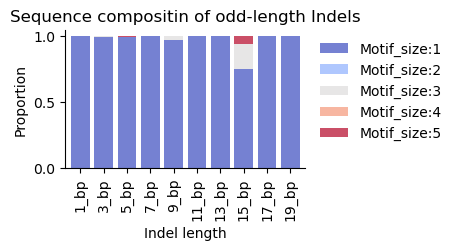

In [14]:
even_ind = [False, True] * 10
odd_ind = [True, False] * 10

fig, axs = plt.subplots(figsize=(3.1, 1.8))

stats_mean_df_ranked.iloc[:,:5].loc[odd_ind,:].plot(kind='bar', alpha = 0.7,
                         stacked=True,ax = axs,
                         colormap= 'coolwarm', width = .8)
axs.set_title("Sequence compositin of odd-length Indels")
sns.despine()
axs.set_ylabel ("Proportion")

axs.set_xlabel ("Indel length")
#axs.set_xticklabels([str(i+1)+ '_bp' for i in range(end_point)], rotation = 90, size = 12)
axs.legend(frameon = False, bbox_to_anchor = (1.01,1))

plt.savefig ("./Figures/MILO_SFig5a.pdf", dpi = 300, bbox_inches = "tight",)
plt.show()

In [15]:
print ("Prevelence of odd-length indels with specific motifs")
stats_mean_df_ranked.iloc[:,:5].loc[odd_ind,:].mean()

Prevelence of odd-length indels with specific motifs


Motif_size:1    0.970917
Motif_size:2    0.000000
Motif_size:3    0.022856
Motif_size:4    0.000000
Motif_size:5    0.006227
dtype: float64

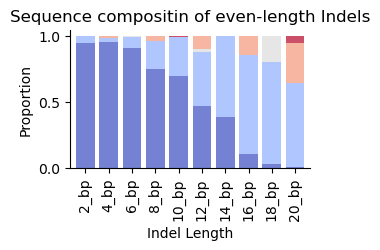

In [16]:
fig, axs = plt.subplots(figsize=(3.1, 1.8))

stats_mean_df_ranked.iloc[:,:5].loc[even_ind,:].plot(kind='bar', alpha = 0.7,
                         stacked=True,ax = axs,
                         colormap= 'coolwarm', width = .8)
axs.set_title("Sequence compositin of even-length Indels")
sns.despine()
axs.set_ylabel ("Proportion")

axs.set_xlabel ("Indel Length")
axs.legend('', frameon = False)

plt.savefig ("./Figures/MILO_SFig5b.pdf", dpi = 300, bbox_inches = "tight",)
plt.show()

In [17]:
print ("Prevelence of even-length indels (<=10bp) with specific motifs")
stats_mean_df_ranked.iloc[:20,:5].loc[even_ind, :].iloc [:5,:].mean()

Prevelence of even-length indels (<=10bp) with specific motifs


Motif_size:1    0.851619
Motif_size:2    0.136488
Motif_size:3    0.001060
Motif_size:4    0.009318
Motif_size:5    0.001517
dtype: float64

In [18]:
print ("Prevelence of even-length indels (>10bp) with specific motifs")
stats_mean_df_ranked.iloc[:20,:5].loc[even_ind, :].iloc [5:,:].mean()

Prevelence of even-length indels (>10bp) with specific motifs


Motif_size:1    0.200845
Motif_size:2    0.636992
Motif_size:3    0.043811
Motif_size:4    0.108723
Motif_size:5    0.009628
dtype: float64

# Slippage events in longitudinal Hartwig samples

In [19]:
new_cols = ['Sample', 'Chrom', 'Pos', 'Profiler_anno', 'Ref', 'Alt', 'unknown', 
            'Original_anno', 'New_anno', 'Context', 'AF', 'CN', 'SUBCL','tag']

In [20]:
## create dataframes
slippage_events_df = pd.DataFrame({patient_id:[0] * 9 for patient_id in all_patient_ids})
slippage_events_df.index = ['total_MS_sample1', 'total_MS_sample2', 'shared_MS', 'Slippage_loci', 
                            'Slippage_1bp', 'Slippage_2bp', 'Slippage_3bp', 'Slippage_4bp', 'Slippage_5bp']

slippage_size_per_motif_non_abs_del = pd.DataFrame()
slippage_size_per_motif_non_abs_ins = pd.DataFrame()

for patient_id in all_patient_ids:
    values = []
    sample1 = patient_id + "T"
    sample2 = patient_id + 'TII'
    
    path = "./Data/paired_metMSI/"
    
    output_sample1 = path + patient_id + "/" + sample1 + "_ID_seqinfo_anno2.txt"
    output_sample2 = path + patient_id + "/" + sample2 + "_ID_seqinfo_anno2.txt"
    
    ## reading data from time point 1
    df_t1 = pd.read_csv (output_sample1, header = None, sep = "\t", low_memory=False)
    df_t1_v2 = df_t1.rename({i:new_cols[i] for i in range (df_t1.shape[1])}, axis = 1).drop (columns = ['unknown', 'Original_anno', 'tag']).copy()
    
    ## reading data from time point 2
    df_t2 = pd.read_csv (output_sample2, header = None, sep = "\t", low_memory=False)
    df_t2_v2 = df_t2.rename({i:new_cols[i] for i in range (df_t2.shape[1])}, axis = 1).drop (columns = ['unknown', 'Original_anno', 'tag']).copy()
    
    ## processing data from time point 1
    df_t1_v2['MS_loci'] =  df_t1_v2['Chrom'].astype("str") + "_" + df_t1_v2['Pos'].astype("str") 
    ms_dict = {}
    for ms in df_t1_v2['MS_loci'].values:
        if ms_dict.get(ms, 0) == 0:
            ms_dict[ms] = 1
        else:
            ms_dict[ms] += 1
    
    uniq_ms_ind = [ms_dict.get(ms)== 1 for ms in df_t1_v2['MS_loci'].values]
    
    ## processing data from time point 2
    df_t1_v2_ms_uniq = df_t1_v2.loc[uniq_ms_ind,:].copy()
    df_t2_v2['MS_loci'] =  df_t2_v2['Chrom'].astype("str") + "_" + df_t2_v2['Pos'].astype("str")
    ms_dict = {}
    for ms in df_t2_v2['MS_loci'].values:
        if ms_dict.get(ms, 0) == 0:
            ms_dict[ms] = 1
        else:
            ms_dict[ms] += 1
            
    uniq_ms_ind = [ms_dict.get(ms)== 1 for ms in df_t2_v2['MS_loci'].values]
    df_t2_v2_ms_uniq = df_t2_v2.loc[uniq_ms_ind,:].copy()
    
    ## merging data frome time point 1 and 2
    df_t1_t2_ms_uniq_merged = df_t1_v2_ms_uniq.merge(df_t2_v2_ms_uniq, on = "MS_loci", suffixes=('_t1', '_t2'))
    
    same_MS_loci = [df_t1_t2_ms_uniq_merged['New_anno_t1'][i][:-4] == df_t1_t2_ms_uniq_merged['New_anno_t2'][i][:-4]
                for i in range (df_t1_t2_ms_uniq_merged.shape[0])]
    
    same_type = [df_t1_t2_ms_uniq_merged['New_anno_t1'][i][:3] == df_t1_t2_ms_uniq_merged['New_anno_t2'][i][:3]
                for i in range (df_t1_t2_ms_uniq_merged.shape[0])]

    diff_MS_loci_same_type = np.logical_and (np.array([not i for i in same_MS_loci]), np.array(same_type))

    df_t1_t2_ms_uniq_merged_changed_ms = df_t1_t2_ms_uniq_merged[diff_MS_loci_same_type].copy()
    
    df_t1_t2_ms_uniq_merged_changed_ms['t1_ID'] = [int(i.split(":")[1]) for i in df_t1_t2_ms_uniq_merged_changed_ms['New_anno_t1']]
    df_t1_t2_ms_uniq_merged_changed_ms['t2_ID'] = [int(i.split(":")[1]) for i in df_t1_t2_ms_uniq_merged_changed_ms['New_anno_t2']]
    
    changes_between_paired_biopsies = df_t1_t2_ms_uniq_merged_changed_ms['t2_ID'].values - df_t1_t2_ms_uniq_merged_changed_ms['t1_ID'].values 

    values += [df_t1_v2_ms_uniq.shape[0], df_t2_v2_ms_uniq.shape[0], df_t1_t2_ms_uniq_merged.shape[0], df_t1_t2_ms_uniq_merged.shape[0] - sum(same_MS_loci)]
    
    for i in range(1,6):
        values.append(sum(np.abs(changes_between_paired_biopsies == i)))
    
    slippage_events_df[patient_id] = values
    
    ## slippage size vs motif size
    motif_size = []
    slippage_size = []
    
    ## searching reasonable range for slippage size
    for i in range(df_t1_t2_ms_uniq_merged.shape[0]):
    
        anno_t1 = df_t1_t2_ms_uniq_merged.loc[:, 'New_anno_t1'].values[i]
        anno_t2 = df_t1_t2_ms_uniq_merged.loc[:, 'New_anno_t2'].values[i]
    
        id_type1, id_len1, motif_size1, repeat_unit1 = anno_t1.split(":")
        id_type2, id_len2, motif_size2, repeat_unit2 = anno_t2.split(":")
    
        repeat_unit1 = int (repeat_unit1)
        repeat_unit2 = int (repeat_unit2)

    
        if id_type1 == 'Del' and id_type1 == id_type2 and motif_size1 == motif_size2:
            slippage_size_tmp = repeat_unit2 - repeat_unit1
            motif_size.append(motif_size1)
            slippage_size.append (slippage_size_tmp)        
        else:
            if id_type1 != id_type2:
                continue
            #print (anno_t1, anno_t2)
            
    pre_defined_slippage_size = list(set (slippage_size))
    abs_index = list((set(np.abs(pre_defined_slippage_size))))
    
    pre_defined_slippage_size = list(set (slippage_size))
    
    ## using pre-defined slippage size range to create data frame
    slippage_size_per_motif_abs = pd.DataFrame({'motif_'+ str(i) : [0] * len(abs_index) for i in range (1,6)})

    slippage_size_per_motif_non_abs_del_tmp = pd.DataFrame({'motif_'+ str(i) : [0] * len(pre_defined_slippage_size) for i in range (1,6)})
    slippage_size_per_motif_non_abs_ins_tmp = pd.DataFrame({'motif_'+ str(i) : [0] * len(pre_defined_slippage_size) for i in range (1,6)})

    slippage_size_per_motif_non_abs_del_tmp.index = np.sort(np.array(pre_defined_slippage_size))
    slippage_size_per_motif_non_abs_ins_tmp.index = np.sort(np.array(pre_defined_slippage_size))
    
    ## going through merged data recording stats
    for i in range(df_t1_t2_ms_uniq_merged.shape[0]):
    
        anno_t1 = df_t1_t2_ms_uniq_merged.loc[:, 'New_anno_t1'].values[i]
        anno_t2 = df_t1_t2_ms_uniq_merged.loc[:, 'New_anno_t2'].values[i]
    
        id_type1, id_len1, motif_size1, repeat_unit1 = anno_t1.split(":")
        id_type2, id_len2, motif_size2, repeat_unit2 = anno_t2.split(":")
    
        repeat_unit1 = int (repeat_unit1)
        repeat_unit2 = int (repeat_unit2)
    
        cont_t1 = df_t1_t2_ms_uniq_merged.loc[:, 'Context_t1'].values[i]
        cont_t2 = df_t1_t2_ms_uniq_merged.loc[:, 'Context_t2'].values[i]

        type1, cont_len1, cont_seq1, cont_repeat_unit1 = cont_t1.split(":")
        type2, cont_len2, cont_seq2, cont_repeat_unit2 = cont_t2.split(":")
    
        if id_type1 == id_type2 and motif_size1 == motif_size2:
        
            if id_type1 == 'Del':
                slippage_size_tmp = repeat_unit2 - repeat_unit1
                slippage_size_per_motif_non_abs_del_tmp.loc[slippage_size_tmp, 'motif_'+ str(motif_size1)] += 1
        
            elif id_type1 == 'Ins':
                slippage_size_tmp = repeat_unit2 - repeat_unit1
                
                if slippage_size_tmp in pre_defined_slippage_size:
                    slippage_size_per_motif_non_abs_ins_tmp.loc[slippage_size_tmp, 'motif_'+ str(motif_size1)] += 1
        else:
            continue
            
        slippage_size_per_motif_non_abs_del_tmp['patient'] = [hmf_patient_ids.get(patient_id, 'Unknown')] * slippage_size_per_motif_non_abs_del_tmp.shape[0]
        slippage_size_per_motif_non_abs_ins_tmp['patient'] = [hmf_patient_ids.get(patient_id, 'Unknown')] * slippage_size_per_motif_non_abs_ins_tmp.shape[0]
    
    ## merging all patient samples together
    slippage_size_per_motif_non_abs_del = pd.concat ((slippage_size_per_motif_non_abs_del, slippage_size_per_motif_non_abs_del_tmp))
    slippage_size_per_motif_non_abs_ins = pd.concat ((slippage_size_per_motif_non_abs_ins, slippage_size_per_motif_non_abs_ins_tmp))

## Shared MS loci between paired biopsies

In [21]:
slippage_events_df.T.loc[:, ['shared_MS',"Slippage_loci"]].sort_values("shared_MS")

,shared_MS,Slippage_loci
DRUP01070020,23710,313
DRUP01070026,37884,4014
CPCT02020704,85376,1275
CPCT02070023,101763,12257
DRUP01010047,190239,25806


In [22]:
perc_heatmap_df = pd.DataFrame({'hmfPatient' : [hmf_patient_ids.get(ind, 'Unknown') for ind in slippage_events_df.T.index],
                                'Patient' : slippage_events_df.T.index,
                                'Biopsy 1' : slippage_events_df.T['shared_MS']/slippage_events_df.T['total_MS_sample1'],
                                'Biopsy 2' : slippage_events_df.T['shared_MS']/slippage_events_df.T['total_MS_sample2']})
perc_heatmap_df.index = perc_heatmap_df['hmfPatient']
perc_heatmap_df

,hmfPatient,Patient,Biopsy 1,Biopsy 2
hmfPatient,,,,
HMF000458,HMF000458,CPCT02070023,0.497548,0.420109
HMF003074,HMF003074,CPCT02020704,0.902161,0.830562
HMF000881,HMF000881,DRUP01070020,0.572429,0.739528
HMF000501,HMF000501,DRUP01070026,0.459133,0.191714
HMF000872,HMF000872,DRUP01010047,0.464300,0.677694


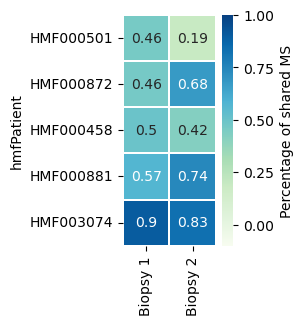

In [23]:
perc_heatmap_df = pd.DataFrame({'hmfPatient' : [hmf_patient_ids.get(ind, 'Unknown') for ind in slippage_events_df.T.index],
                                'Patient' : slippage_events_df.T.index,
                                'Biopsy 1' : slippage_events_df.T['shared_MS']/slippage_events_df.T['total_MS_sample1'],
                                'Biopsy 2' : slippage_events_df.T['shared_MS']/slippage_events_df.T['total_MS_sample2']})
perc_heatmap_df.index = perc_heatmap_df['hmfPatient']

ax, f = plt.subplots(figsize = (1.5,3))
cmap = sns.cubehelix_palette(light=1, as_cmap=True)
sns.heatmap(perc_heatmap_df.sort_values('Biopsy 1').iloc[:,2:], annot = True, vmin=1, vmax=0, 
                cmap = "GnBu", linewidths=.2,
           cbar_kws = {'shrink': 1, 'ticks' : np.linspace(0, 1,5), 
                        'label': f"Percentage of shared MS"})
plt.savefig("./Figures/MILO_Fig2b.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

## Slippage event in shared mutated MS loci

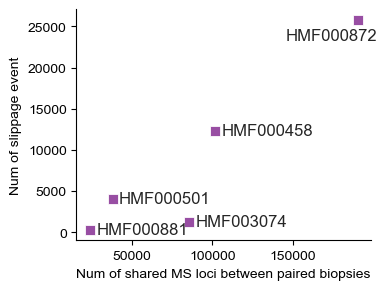

In [24]:
ax, f = plt.subplots(figsize = (3.8,3))

sns.set(style="whitegrid", color_codes=True, rc={"grid.linewidth": .5, 'grid.color': '.7', 'ytick.major.size': 2,
                                                'axes.edgecolor': '.3', 'axes.linewidth': 1.35,})
sns.scatterplot(x = 'shared_MS', y = "Slippage_loci", 
                data = slippage_events_df.T, color = sns.color_palette("Set1")[3], marker= ',', s = 50)
plt.xlabel("Num of shared MS loci between paired biopsies")
plt.ylabel("Num of slippage event")
for i in range(5):
    if i < 4:
        plt.annotate(hmf_patient_ids.get(slippage_events_df.T.index[i],'Unknown'),
                     (slippage_events_df.T['shared_MS'][i] + 4000,
                      slippage_events_df.T["Slippage_loci"][i] - 500))
    else:
        plt.annotate(hmf_patient_ids.get(slippage_events_df.T.index[i],'Unknown'),
                     (slippage_events_df.T['shared_MS'][i] - 45000,
                      slippage_events_df.T["Slippage_loci"][i] - 2500))

sns.despine()
plt.savefig("./Figures/MILO_Fig2c.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

## Slippage size frequencies

In [25]:
wide_form_slippage_df = (slippage_events_df.T.iloc[:, 4:].div(slippage_events_df.T.iloc[:, 4:].sum(axis = 1), axis = 0)).T
long_form_slippage_df = pd.melt(wide_form_slippage_df.reset_index(), id_vars='index')

In [26]:
wide_form_slippage_df

,CPCT02070023,CPCT02020704,DRUP01070020,DRUP01070026,DRUP01010047
Slippage_1bp,0.779157,0.894549,0.945312,0.780606,0.841039
Slippage_2bp,0.177528,0.095621,0.050781,0.174949,0.136681
Slippage_3bp,0.031549,0.004468,0.000000,0.027475,0.015180
Slippage_4bp,0.009956,0.004468,0.000000,0.014545,0.006407
Slippage_5bp,0.001810,0.000894,0.003906,0.002424,0.000693


In [27]:
wide_form_slippage_df.mean(axis = 1)

Slippage_1bp    0.848133
Slippage_2bp    0.127112
Slippage_3bp    0.015734
Slippage_4bp    0.007075
Slippage_5bp    0.001945
dtype: float64

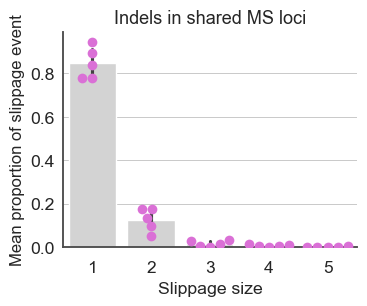

In [28]:
f, ax = plt.subplots(figsize = (3.8,2.8))
sns.barplot(x = "index", y = "value", data = long_form_slippage_df, color = "lightgrey" , width = 0.8)
sns.swarmplot(x = "index", y = "value", data = long_form_slippage_df, color = '#DA70D6', size = 7)
#plt.xticks(rotation =30)
sns.despine()
plt.xlabel("Slippage size", size = 12.7)
plt.xticks(range(5), [str(i+1) for i in range(5)], size = 12.5)

plt.ylabel("Mean proportion of slippage event")
plt.yticks( size = 12.7)
plt.title("Indels in shared MS loci", fontsize = 13)
plt.savefig("./Figures/MILO_Fig2d.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

## Slippage size vs motif length

In [29]:
def heatmap_slippagesize_motifsize (df_tmp, p_id, tp, fs = (5,3)):
    f, ax = plt.subplots (figsize = fs)

    cmap = sns.cubehelix_palette(light=1, as_cmap=True) # "viridis"

    ax = sns.heatmap(np.log10(df_tmp.loc[df_tmp.sum(axis = 1) > 10,:] + 1), 
                     vmin = 0, vmax = 5.5, cmap = cmap, linewidths=.1, annot=True,
                    cbar_kws = {'shrink': .5, 'ticks' : np.linspace(0, 6,5), 'label': f"log10(slippage_size count)"},
                    annot_kws={"size": 10})
    
    ax.set(xlabel="Motif size", ylabel="Slippage size", title = p_id + " (" + tp + " in shared MS loci)")

    plt.savefig ("./Figures/MILO_SFig6_" + tp + " " + p_id + ".pdf", bbox_inches = "tight", dpi = 300)

    plt.show()

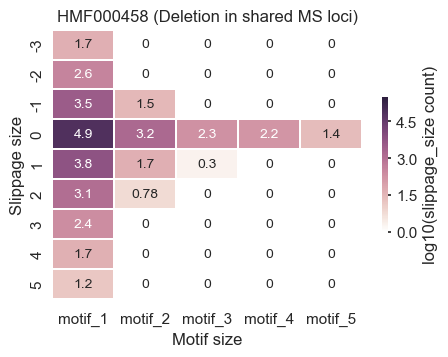

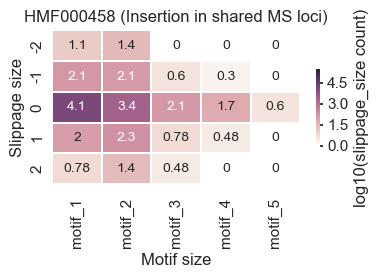

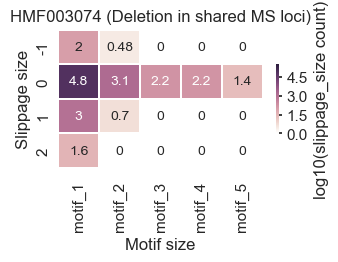

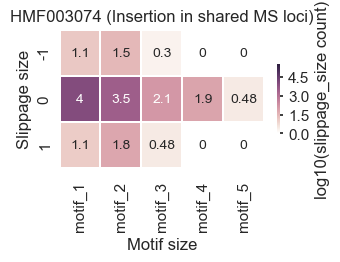

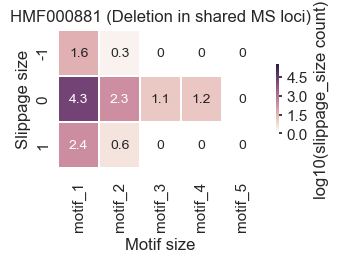

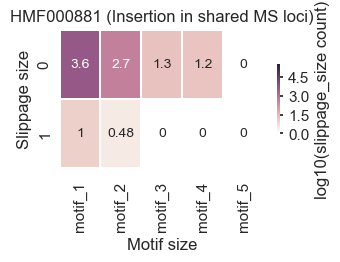

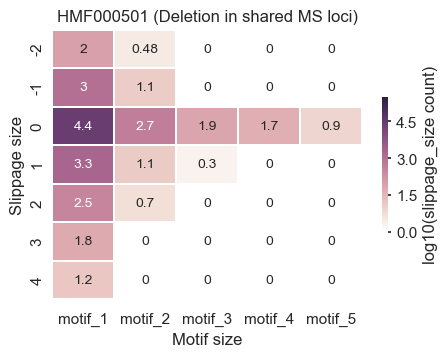

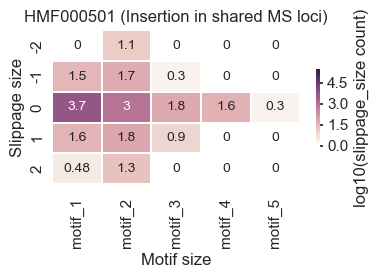

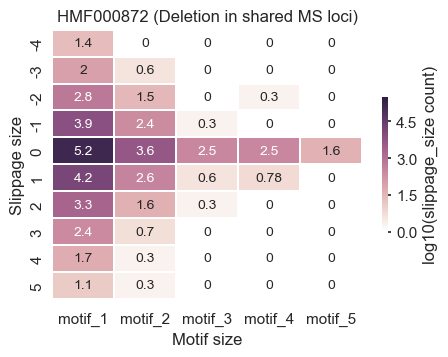

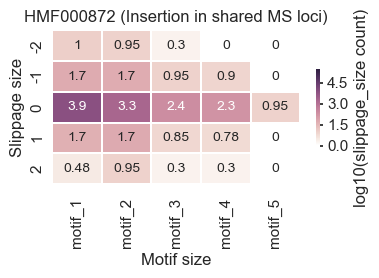

In [30]:
for patient_id in all_patient_ids:
    
    p_id = hmf_patient_ids.get(patient_id)
    
    slippage_size_per_motif_non_abs_del_per_patient = slippage_size_per_motif_non_abs_del.groupby('patient').get_group(p_id)
    slippage_size_per_motif_non_abs_ins_per_patient = slippage_size_per_motif_non_abs_ins.groupby('patient').get_group(p_id)
    
    df_del_tmp = slippage_size_per_motif_non_abs_del_per_patient.drop('patient', axis = 1).copy()
    df_ins_tmp = slippage_size_per_motif_non_abs_ins_per_patient.drop('patient', axis = 1).copy()
    
        
    if p_id not in ['HMF003074','HMF000881']:
        heatmap_slippagesize_motifsize (df_del_tmp, p_id, 'Deletion', (5,3.5))
        heatmap_slippagesize_motifsize (df_ins_tmp, p_id, 'Insertion', (4,2))
        
    else:
        heatmap_slippagesize_motifsize (df_del_tmp, p_id, 'Deletion', (3.3,1.8))
        heatmap_slippagesize_motifsize (df_ins_tmp, p_id, 'Insertion', (3.3,1.8))

In [31]:
shared_uniq_MS_del = []
shared_uniq_MS_ins = []

slippage_event_per_motif_size_del_df = pd.DataFrame()
slippage_event_per_motif_size_ins_df = pd.DataFrame()

for patient_id in all_patient_ids:
    
    p_id = hmf_patient_ids.get(patient_id)
    
    slippage_size_per_motif_non_abs_del_per_patient = slippage_size_per_motif_non_abs_del.groupby('patient').get_group(p_id)
    slippage_size_per_motif_non_abs_ins_per_patient = slippage_size_per_motif_non_abs_ins.groupby('patient').get_group(p_id)
    
    df_del_tmp = slippage_size_per_motif_non_abs_del_per_patient.drop('patient', axis = 1).copy()
    df_ins_tmp = slippage_size_per_motif_non_abs_ins_per_patient.drop('patient', axis = 1).copy()
    
    total_del = df_del_tmp.sum().sum()
    total_ins = df_ins_tmp.sum().sum()
    total = total_del + total_ins
    
    shared_uniq_MS_del.append(total_del/total)
    shared_uniq_MS_ins.append(total_ins/total)
    
    slippage_event_per_motif_size_del = df_del_tmp.loc[df_del_tmp.index != 0,:].sum()
    
    if slippage_event_per_motif_size_del.sum() > 20:
        slippage_event_per_motif_size_del_df[p_id] = (slippage_event_per_motif_size_del/slippage_event_per_motif_size_del.sum()).values
    
    slippage_event_per_motif_size_ins = df_ins_tmp.loc[df_ins_tmp.index != 0,:].sum()
    
    if slippage_event_per_motif_size_ins.sum() > 20:
        slippage_event_per_motif_size_ins_df[p_id] = (slippage_event_per_motif_size_ins/slippage_event_per_motif_size_ins.sum()).values

In [32]:
print ("percentage of del and ins in shared MS loci")
'del:', np.mean(np.array(shared_uniq_MS_del)), 'ins:', np.mean(np.array(shared_uniq_MS_ins))

percentage of del and ins in shared MS loci


('del:', 0.8590030556200722, 'ins:', 0.14099694437992788)

In [33]:
slippage_event_per_motif_size_del_df['motif_size'] = slippage_event_per_motif_size_del.index
slippage_event_per_motif_size_del_df_long = pd.melt(slippage_event_per_motif_size_del_df, id_vars = ['motif_size'])

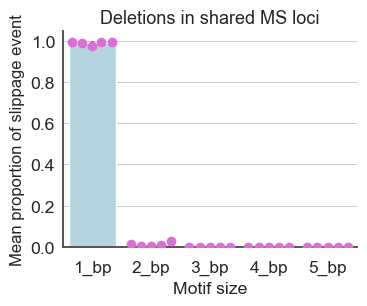

In [34]:
f, ax = plt.subplots(figsize = (3.8,2.8))
sns.barplot(x = "motif_size", y = "value", data = slippage_event_per_motif_size_del_df_long, color = "lightblue" , width = 0.8)
sns.swarmplot(x = "motif_size", y = "value", data = slippage_event_per_motif_size_del_df_long, color = '#DA70D6', size = 7)
#plt.xticks(rotation =30)
sns.despine()
plt.xlabel("Motif size", size = 12.7)
plt.xticks(range(5), [str(i+1) + "_bp" for i in range(5)], size = 12.5)

plt.ylabel("Mean proportion of slippage event")
plt.yticks( size = 12.7)
plt.title("Deletions in shared MS loci",fontsize = 13)

plt.savefig("./Figures/MILO_Fig2e.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

In [35]:
print ("prevelence of slippage events at specific motifs (deletions in shared MS loci)")
slippage_event_per_motif_size_del_df.set_index("motif_size").mean(axis = 1)

prevelence of slippage events at specific motifs (deletions in shared MS loci)


motif_size
motif_1    0.987342
motif_2    0.012497
motif_3    0.000114
motif_4    0.000047
motif_5    0.000000
dtype: float64

In [36]:
slippage_event_per_motif_size_ins_df['motif_size']= slippage_event_per_motif_size_ins.index
slippage_event_per_motif_size_ins_df_long = pd.melt(slippage_event_per_motif_size_ins_df, id_vars = ['motif_size'])

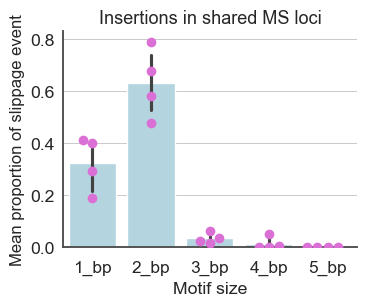

In [37]:
f, ax = plt.subplots(figsize = (3.8,2.8))
sns.barplot(x = "motif_size", y = "value", data = slippage_event_per_motif_size_ins_df_long, color = "lightblue" , width = 0.8)
sns.swarmplot(x = "motif_size", y = "value", data = slippage_event_per_motif_size_ins_df_long, color = '#DA70D6', size = 7)
#plt.xticks(rotation =30)
sns.despine()
plt.xlabel("Motif size", size = 12.7)
plt.xticks(range(5), [str(i+1) + '_bp' for i in range(5)], size = 12.5)

plt.ylabel("Mean proportion of slippage event")
plt.yticks( size = 12.7)
plt.title("Insertions in shared MS loci", fontsize = 13)
plt.savefig("./Figures/MILO_Fig2f.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

In [38]:
print ("prevelence of slippage events at specific motifs (insertions in shared MS loci)")
slippage_event_per_motif_size_ins_df.set_index("motif_size").mean(axis = 1)

prevelence of slippage events at specific motifs (insertions in shared MS loci)


motif_size
motif_1    0.322934
motif_2    0.630396
motif_3    0.033202
motif_4    0.013468
motif_5    0.000000
dtype: float64